# Block 4 — Optimizing & Training Linear Models: Gradient Descent & L1/L2/Elasticnet
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing_features.csv` (Block 3's output) — no new CSV comes out of this block, we're training
models on the feature set we already built.

**What we'll do in this notebook:**
1. Prep the feature set for a linear model (and notice what we're deliberately leaving in it)
2. Watch gradient descent actually converge, from scratch, on one feature — and watch it *fail* to converge with a
   bad learning rate
3. Quantify the `duration` leakage we flagged back in Block 3, side by side
4. Fit L1, L2, and Elasticnet logistic regression and see, in our own coefficients, what each penalty actually does
   with the redundant feature pairs already sitting in our data


## 1. Setup

In [ ]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for bank_marketing_features.csv below, then remove the leading '#':
# df = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";")
print(df.shape)
df.head()


## 2. Prepping the Feature Set for a Linear Model

Two things need handling before any of this can go into `LogisticRegression`:

- **`education`** is still a raw string column — Block 3 derived `education_rank` from it but never dropped the
  original. A linear model needs fully numeric input, so it has to go.
- **We're deliberately leaving two redundant pairs in place**: raw `age` alongside the one-hot `age_band_*` columns,
  and each raw macro-economic column alongside its PCA-denoised `_denoised` sibling from Block 3. Normally you'd
  clean this up before modeling — today we're keeping the redundancy on purpose, because watching L1 and L2 handle
  it differently *is* the lesson in Section 4.


In [2]:
feature_cols = [c for c in df.columns if c not in ("education", "y")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]
print(f"{len(feature_cols)} candidate features, {len(bool_cols)} one-hot/boolean columns among them")

numeric_to_scale = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "education_rank", "month_sin", "month_cos", "campaign_intensity",
    "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
    "euribor3m_denoised", "nr.employed_denoised",
]

X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)


48 candidate features, 28 one-hot/boolean columns among them
train: (32950, 48)  test: (8238, 48)


In [3]:
scaler = StandardScaler()
X_train[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

X_train[numeric_to_scale].describe().loc[["mean", "std"]].round(2)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,education_rank,month_sin,month_cos,campaign_intensity,emp.var.rate_denoised,cons.price.idx_denoised,cons.conf.idx_denoised,euribor3m_denoised,nr.employed_denoised
mean,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Why scale at all?** Gradient descent and every penalty term below operate directly on the coefficient values —
if `nr.employed` (~5,000s) and `month_sin` (-1 to 1) are left on their raw scales, the optimizer takes wildly
different step sizes across features, and a fixed penalty shrinks the small-scale feature into irrelevance long
before it touches the large-scale one. Scaling puts every feature on equal footing before either gradient descent
or regularization ever sees it. One-hot columns are already 0/1, so we leave those alone.


## 3. Gradient Descent, From Scratch

`LogisticRegression.fit()` hides the mechanics — underneath, it's the same loop every time: guess some
coefficients, measure how wrong they are, nudge them in the direction that reduces the error, repeat. Let's write
that loop ourselves on a single feature (`duration`, scaled) so the convergence — and what happens when it goes
wrong — is visible.


In [4]:
def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1 / (1 + np.exp(-z))

def logistic_loss(X, y, w, b):
    p = sigmoid(X @ w + b)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

def gradient_descent(X, y, lr, n_iter=150):
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for _ in range(n_iter):
        p = sigmoid(X @ w + b)
        grad_w = X.T @ (p - y) / n
        grad_b = np.mean(p - y)
        w -= lr * grad_w
        b -= lr * grad_b
        losses.append(logistic_loss(X, y, w, b))
    return w, b, losses


In [5]:
# One feature, on its own scale, so we can watch the descent clearly
demo_sample = df.sample(5000, random_state=1)
dur_scaled = StandardScaler().fit_transform(demo_sample[["duration"]])
y_demo = demo_sample["y"].values.astype(float)

learning_rates = {"Too small (lr=0.02)": 0.02, "Well-tuned (lr=0.5)": 0.5, "Too large (lr=25)": 25.0}
runs = {name: gradient_descent(dur_scaled, y_demo, lr) for name, lr in learning_rates.items()}

for name, (w, b, losses) in runs.items():
    print(f"{name:24s} final loss = {losses[-1]:.3f}   (started at {losses[0]:.3f})")


Too small (lr=0.02)      final loss = 0.432   (started at 0.690)
Well-tuned (lr=0.5)      final loss = 0.297   (started at 0.616)
Too large (lr=25)        final loss = 0.528   (started at 0.779)


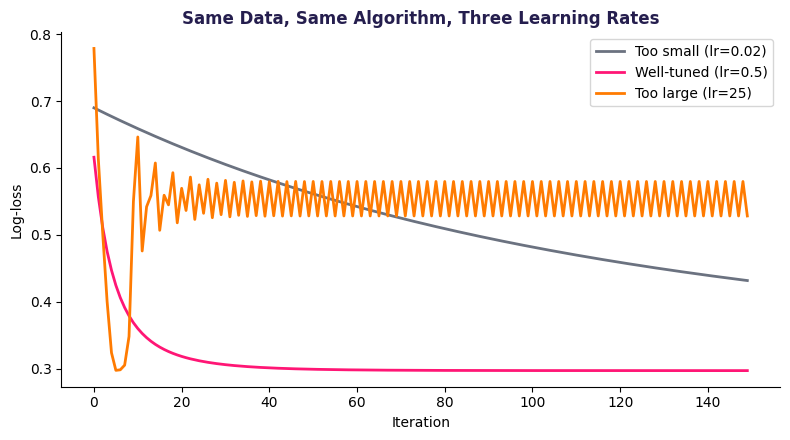

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"Too small (lr=0.02)": GRAY, "Well-tuned (lr=0.5)": PINK, "Too large (lr=25)": ORANGE}
for name, (w, b, losses) in runs.items():
    ax.plot(losses, label=name, color=colors[name], linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Log-loss")
ax.set_title("Same Data, Same Algorithm, Three Learning Rates", color=NAVY, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**What's happening in each line:**
- **Too small** barely moves in 150 iterations — it's still descending, just too slowly to be useful; give it enough
  iterations and it eventually gets there, but that's wasted compute every time you retrain.
- **Well-tuned** drops fast and flattens out at the actual minimum — this is what convergence is supposed to look
  like.
- **Too large** overshoots the minimum on every step and oscillates around it instead of settling — more iterations
  won't fix this, only a smaller learning rate will. Push it further and the same pattern turns into outright
  divergence.

This is exactly the "learning rate" hyperparameter you'll see on every `SGDClassifier` or neural network you touch
for the rest of the course — same failure modes, same fix.


## 4. The Leakage Feature: `duration`

Flagged back in Block 3 and left untouched on purpose: `duration` is call length in seconds, only known once the
call has ended. A model scoring a call *in progress* can never see it — so a production model trained with it is
being graded on an answer it won't actually have. Let's put a number on how much that's worth.


In [7]:
cols_no_duration = [c for c in feature_cols if c != "duration"]

t0 = time.time()
model_with = LogisticRegression(max_iter=2000, solver="lbfgs")
model_with.fit(X_train, y_train)
proba_with = model_with.predict_proba(X_test)[:, 1]

model_without = LogisticRegression(max_iter=2000, solver="lbfgs")
model_without.fit(X_train[cols_no_duration], y_train)
proba_without = model_without.predict_proba(X_test[cols_no_duration])[:, 1]

leakage_summary = pd.DataFrame({
    "Model": ["WITH duration (leaky)", "WITHOUT duration (defensible)"],
    "Accuracy": [
        accuracy_score(y_test, model_with.predict(X_test)),
        accuracy_score(y_test, model_without.predict(X_test[cols_no_duration])),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, proba_with),
        roc_auc_score(y_test, proba_without),
    ],
}).round(4)
print(f"fit time: {time.time() - t0:.2f}s total")
leakage_summary


fit time: 1.02s total


,Model,Accuracy,ROC-AUC
0,WITH duration (leaky),0.9132,0.9363
1,WITHOUT duration (defensible),0.8997,0.7959


Notice **accuracy barely moves** — the dataset is imbalanced (88.7% "no"), so accuracy is a weak signal either way,
and that gap is exactly why Block 6 spends a full block on metrics that don't get fooled this easily. **ROC-AUC
tells the real story**: dropping `duration` costs a large, visible chunk of discriminative power. That entire gap
was the model leaning on information it will never have at scoring time.


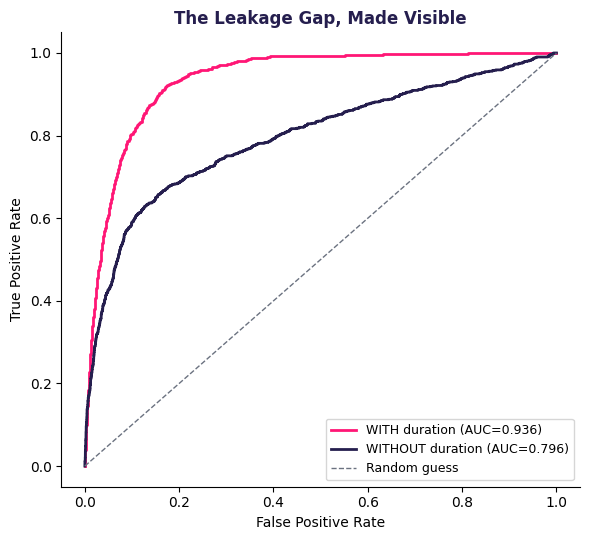

In [8]:
fpr_with, tpr_with, _ = roc_curve(y_test, proba_with)
fpr_without, tpr_without, _ = roc_curve(y_test, proba_without)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr_with, tpr_with, color=PINK, linewidth=2,
        label=f"WITH duration (AUC={roc_auc_score(y_test, proba_with):.3f})")
ax.plot(fpr_without, tpr_without, color=NAVY, linewidth=2,
        label=f"WITHOUT duration (AUC={roc_auc_score(y_test, proba_without):.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("The Leakage Gap, Made Visible", color=NAVY, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Model risk framing:** a model that "performs great" because of one feature like this isn't a good model — it's a
finding waiting to happen the moment a validator asks "is this feature known at scoring time?" From here on, every
model in this course is trained **without** `duration`.


## 5. L1 vs L2 vs Elasticnet — What Regularization Actually Does to *Our* Coefficients

We already know two redundant pairs are sitting in this feature set: `age` next to `age_band_*`, and each macro
column next to its `_denoised` twin. Instead of cleaning that up by hand, let's see what each penalty does with it
automatically.


In [9]:
X_train_reg = X_train[cols_no_duration]
X_test_reg = X_test[cols_no_duration]

penalty_configs = {
    "L2 (Ridge)": dict(l1_ratio=0.0),
    "L1 (Lasso)": dict(l1_ratio=1.0),
    "Elasticnet": dict(l1_ratio=0.5),
}

fitted = {}
rows = []
for name, kwargs in penalty_configs.items():
    t0 = time.time()
    m = LogisticRegression(max_iter=20000, solver="saga", C=0.5, random_state=42, **kwargs)
    m.fit(X_train_reg, y_train)
    proba = m.predict_proba(X_test_reg)[:, 1]
    n_nonzero = int(np.sum(np.abs(m.coef_[0]) > 1e-4))
    fitted[name] = m
    rows.append({
        "Penalty": name,
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4),
        "Nonzero coefficients": f"{n_nonzero} / {len(m.coef_[0])}",
        "Iterations used": f"{int(m.n_iter_[0])} / {m.max_iter}",
        "Fit time (s)": round(time.time() - t0, 1),
    })

pd.DataFrame(rows)

,Penalty,ROC-AUC,Nonzero coefficients,Iterations used,Fit time (s)
0,L2 (Ridge),0.7958,47 / 47,272 / 20000,6.0
1,L1 (Lasso),0.7962,36 / 47,314 / 20000,6.3
2,Elasticnet,0.7960,40 / 47,582 / 20000,13.4


All three land at essentially the same ROC-AUC — regularization here isn't buying predictive power, it's buying
**stability and a simpler story to defend in documentation**. The nonzero-coefficient count is where the three
penalties actually diverge: L2 keeps every single feature, Elasticnet drops some, L1 drops the most. That's the
sparsity spectrum in one table.

**Reproducibility note:** `saga` is a stochastic solver — without a fixed `random_state` and enough `max_iter` to
actually reach convergence, these coefficients (especially which ones L1 zeroes out) can vary between runs and
environments. Both are set explicitly above, and the *Iterations used* column confirms the solver converged well
within its cap rather than being cut off.

In [10]:
coef_l1 = pd.Series(fitted["L1 (Lasso)"].coef_[0], index=X_train_reg.columns)
coef_l2 = pd.Series(fitted["L2 (Ridge)"].coef_[0], index=X_train_reg.columns)

age_band_cols = [c for c in X_train_reg.columns if c.startswith("age_band_")]
age_pair_rows = [{"Feature": "age (raw)", "L1 coef": coef_l1["age"], "L2 coef": coef_l2["age"]}]
for c in age_band_cols:
    age_pair_rows.append({"Feature": c, "L1 coef": coef_l1[c], "L2 coef": coef_l2[c]})

age_pair_table = pd.DataFrame(age_pair_rows).round(4)
age_pair_table


,Feature,L1 coef,L2 coef
0,age (raw),0.0000,0.0286
1,age_band_26-35,-0.1442,-0.1917
2,age_band_36-45,-0.2649,-0.3344
3,age_band_46-55,-0.1927,-0.2905
4,age_band_56-65,0.0000,-0.1251
5,age_band_66+,0.2127,0.0739


L1 zeroes the raw `age` coefficient out completely and leans entirely on the `age_band_*` bins instead — it picked
one representation of "age" and dropped the other. L2 keeps a small residual weight on raw `age` too; it never
fully commits, it just shrinks everything toward zero together.


In [11]:
macro_cols = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
macro_pair_rows = []
for base in macro_cols:
    den = base + "_denoised"
    macro_pair_rows.append({
        "Macro column": base,
        "L1 (raw)": coef_l1[base], "L1 (denoised)": coef_l1[den],
        "L2 (raw)": coef_l2[base], "L2 (denoised)": coef_l2[den],
    })
macro_pair_table = pd.DataFrame(macro_pair_rows).round(4)
macro_pair_table


,Macro column,L1 (raw),L1 (denoised),L2 (raw),L2 (denoised)
0,emp.var.rate,-1.0703,0.0,-0.9768,-0.0799
1,cons.price.idx,0.7152,0.0,0.5615,0.1838
2,cons.conf.idx,0.2120,0.0,0.1614,0.0649
3,euribor3m,-0.1596,0.0,-0.1436,-0.1266
4,nr.employed,0.0896,0.0,0.4048,-0.2338


Even more dramatic: L1 zeroes out **every single `_denoised` column** and keeps only the raw macro features — given
two near-identical copies of the same signal, it picks one and throws the other away entirely. L2 does the opposite
instinct: it splits the weight across both the raw and denoised versions of each column, because shrinking two
correlated coefficients together costs it less than committing to either one alone. Same data, same redundancy,
genuinely different behavior — this is the concrete version of the "L1 selects, L2 shrinks" rule.


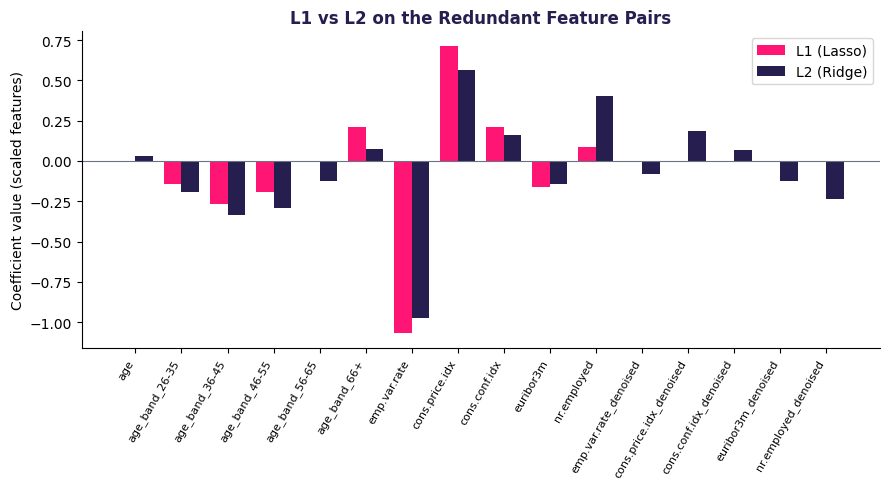

In [12]:
compare_cols = ["age"] + age_band_cols + macro_cols + [c + "_denoised" for c in macro_cols]
plot_df = pd.DataFrame({"L1 (Lasso)": coef_l1[compare_cols], "L2 (Ridge)": coef_l2[compare_cols]})

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(compare_cols))
width = 0.38
ax.bar(x - width/2, plot_df["L1 (Lasso)"], width, label="L1 (Lasso)", color=PINK)
ax.bar(x + width/2, plot_df["L2 (Ridge)"], width, label="L2 (Ridge)", color=NAVY)
ax.axhline(0, color=GRAY, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(compare_cols, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Coefficient value (scaled features)")
ax.set_title("L1 vs L2 on the Redundant Feature Pairs", color=NAVY, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Talking point:** which penalty would you rather hand a model validator? L1's shorter, sparser coefficient list is
easier to explain line by line — but it made an arbitrary-looking call (why keep raw `nr.employed` and drop its
denoised twin specifically?) that you'd need to be ready to justify. L2's answer is less surprising but touches
every feature, which is its own documentation burden. Elasticnet exists precisely to let you tune that trade-off
instead of picking a side.


## Recap

- Gradient descent is the same loop everywhere: guess, measure the error, step opposite the gradient, repeat — and
  the learning rate is the one knob that decides whether that loop converges, crawls, or blows up.
- `duration` was a large, quantified leakage gap in ROC-AUC hiding behind a nearly-unchanged accuracy number — a
  preview of why Block 6 spends a full block on evaluation metrics. Every model from here forward drops it.
- L1, L2, and Elasticnet reached the same predictive performance on our data but made very different decisions
  about the redundant `age`/`age_band` and macro/denoised feature pairs already sitting in `bank_marketing_features.csv`
  — L1 selects and drops, L2 shrinks and shares, Elasticnet blends the two.
- No new CSV comes out of this block — `bank_marketing_features.csv` carries forward unchanged into Block 5.

**Up next — Block 5:** Linear Models — SVM & k-Fold Cross-Validation.
